# Data Sanity Check

Visual inspection of generated 3-body trajectories.
- Static trajectory plots
- Energy conservation check
- Animated trajectories

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

with h5py.File("output/train.h5", "r") as f:
    trajectories = f["trajectories"][:]
    energies = f["energies"][:]
    meta = dict(f["metadata"].attrs)

print(f"trajectories shape: {trajectories.shape}")
print(f"energies shape:     {energies.shape}")
print(f"metadata: {meta}")

: 

## Static trajectory plots

Plot x-y paths for a few trajectories. Each color is one particle.

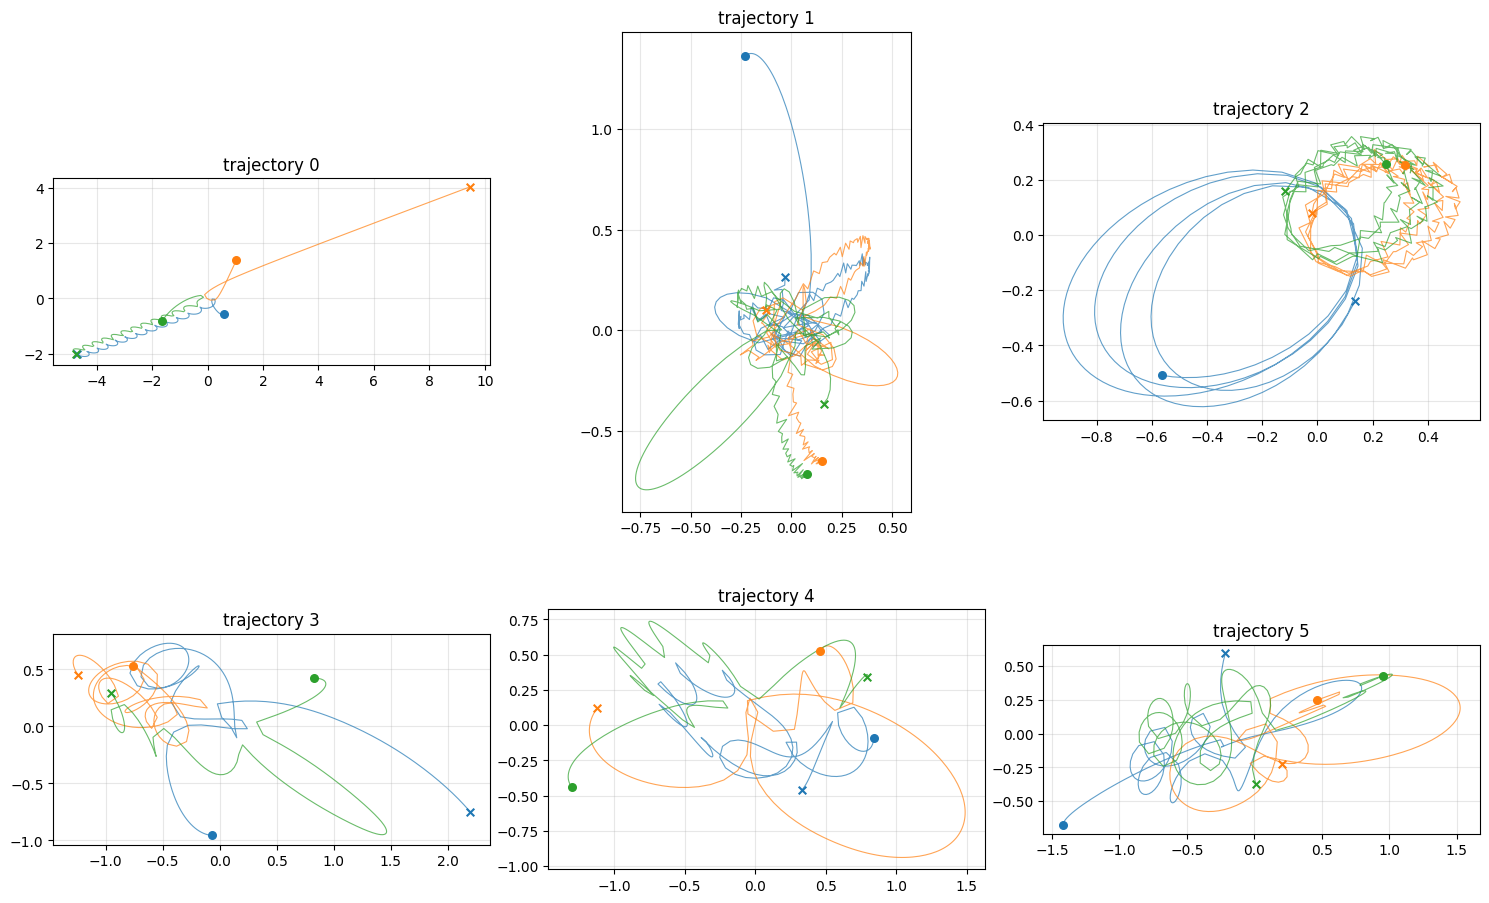

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
colors = ["tab:blue", "tab:orange", "tab:green"]

for idx, ax in enumerate(axes.flat):
    traj = trajectories[idx]  # (200, 3, 4)
    for p in range(3):
        ax.plot(traj[:, p, 0], traj[:, p, 1], color=colors[p], alpha=0.7, linewidth=0.8)
        ax.scatter(traj[0, p, 0], traj[0, p, 1], color=colors[p], marker="o", s=30, zorder=5)
        ax.scatter(traj[-1, p, 0], traj[-1, p, 1], color=colors[p], marker="x", s=30, zorder=5)
    ax.set_title(f"trajectory {idx}")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Energy conservation

IAS15 should conserve energy to machine precision. Plot relative energy error for a few trajectories.

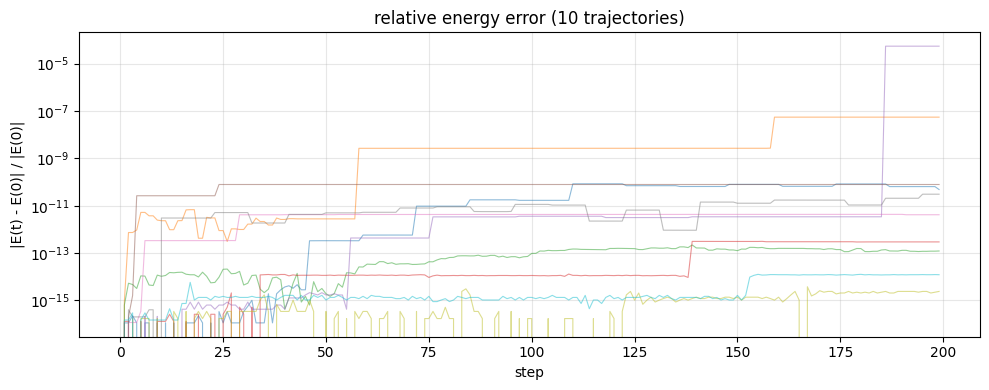

max relative energy error across all trajectories: 2.34e+01
mean relative energy error at final step:         2.50e-02


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))

for idx in range(10):
    e = energies[idx]
    rel_error = np.abs((e - e[0]) / e[0])
    ax.plot(rel_error, alpha=0.5, linewidth=0.8)

ax.set_xlabel("step")
ax.set_ylabel("|E(t) - E(0)| / |E(0)|")
ax.set_title("relative energy error (10 trajectories)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# summary stats across all trajectories
all_rel_errors = np.abs((energies - energies[:, 0:1]) / energies[:, 0:1])
print(f"max relative energy error across all trajectories: {all_rel_errors.max():.2e}")
print(f"mean relative energy error at final step:         {all_rel_errors[:, -1].mean():.2e}")

## Animated trajectory

Pick one trajectory and animate the 3 particles moving.

In [ ]:
traj_idx = 3
traj = trajectories[traj_idx]  # (200, 3, 4)
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(7, 7))

# compute axis limits from full trajectory with some padding
all_x = traj[:, :, 0]
all_y = traj[:, :, 1]
pad = 0.5
ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
ax.set_ylim(all_y.min() - pad, all_y.max() + pad)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.set_title(f"trajectory {traj_idx}")

# trail lines and particle dots
trails = [ax.plot([], [], color=c, alpha=0.4, linewidth=0.8)[0] for c in colors]
dots = [ax.plot([], [], "o", color=c, markersize=8)[0] for c in colors]


def _init() -> list:
    """Initialize animation artists."""
    for trail, dot in zip(trails, dots, strict=True):
        trail.set_data([], [])
        dot.set_data([], [])
    return trails + dots


def _update(frame: int) -> list:
    """Update animation artists for a given frame."""
    for p in range(3):
        trails[p].set_data(traj[: frame + 1, p, 0], traj[: frame + 1, p, 1])
        dots[p].set_data([traj[frame, p, 0]], [traj[frame, p, 1]])
    return trails + dots


anim = FuncAnimation(fig, _update, init_func=_init, frames=len(traj), interval=50, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

: 